In [1]:

!pip install -q sentencepiece==0.2.0 bert-score==0.3.13 nltk==3.9.1 sacremoses 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 67.2 MB/s eta 0:00:00


In [2]:


import importlib, sys
try:
    import torch
except ImportError:
    !pip install -q torch

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("Dependencies ready.")

Dependencies ready.


In [3]:
import os, math, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:

TRAIN_SA = "train_sa_10000.csv"
TRAIN_EN = "train_en_10000.csv"
DEV_SA   = "dev_sa_1000.csv"
DEV_EN   = "dev_en_1000.csv"
TEST_SA  = "test_sa_1000.csv"
TEST_EN  = "test_en_1000.csv"

# ---------------- HYPERPARAMETERS ----------------
CFG = dict(
    src_vocab   = 8000,
    tgt_vocab   = 8000,
    d_model     = 256,
    n_heads     = 8,
    n_enc       = 4,
    n_dec       = 4,
    d_ff        = 1024,
    dropout     = 0.3,
    max_len     = 128,
    batch_size  = 64,
    lr          = 1.0,
    warmup      = 4000,
    label_smooth= 0.1,
    epochs      = 40,
    patience    = 6,
    grad_clip   = 1.0,
    beam_size   = 5,
    length_alpha= 0.7,
)


PAD, BOS, EOS, UNK = 0, 1, 2, 3
for k, v in CFG.items():
    print(f"{k:12s}: {v}")

src_vocab   : 8000
tgt_vocab   : 8000
d_model     : 256
n_heads     : 8
n_enc       : 4
n_dec       : 4
d_ff        : 1024
dropout     : 0.3
max_len     : 128
batch_size  : 64
lr          : 1.0
warmup      : 4000
label_smooth: 0.1
epochs      : 40
patience    : 6
grad_clip   : 1.0
beam_size   : 5
length_alpha: 0.7


In [5]:
def load_pairs(sa_path, en_path, drop_empty=True):
    sa = pd.read_csv(sa_path)
    en = pd.read_csv(en_path)
    df = sa.merge(en, on="Source_id", how="inner")
    df["Sentence_sa"] = df["Sentence_sa"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    df["Sentence_en"] = df["Sentence_en"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    if drop_empty:
        df = df[(df["Sentence_sa"].str.len() > 0) & (df["Sentence_en"].str.len() > 0)]
    return df.reset_index(drop=True)

train_df = load_pairs(TRAIN_SA, TRAIN_EN)
dev_df   = load_pairs(DEV_SA, DEV_EN)

print("Train pairs:", len(train_df))
print("Dev   pairs:", len(dev_df))
train_df.head(3)

Train pairs: 10000
Dev   pairs: 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


In [6]:

sa_lens = train_df.Sentence_sa.str.split().apply(len)
en_lens = train_df.Sentence_en.str.split().apply(len)
print("Sanskrit words/sentence  -> mean {:.1f}, 95th pct {:.0f}, max {}".format(
    sa_lens.mean(), sa_lens.quantile(0.95), sa_lens.max()))
print("English  words/sentence  -> mean {:.1f}, 95th pct {:.0f}, max {}".format(
    en_lens.mean(), en_lens.quantile(0.95), en_lens.max()))

Sanskrit words/sentence  -> mean 9.7, 95th pct 20, max 55
English  words/sentence  -> mean 12.6, 95th pct 28, max 116


In [7]:
def train_spm(sentences, prefix, vocab_size):
    corpus = f"{prefix}_corpus.txt"
    with open(corpus, "w", encoding="utf-8") as f:
        f.write("\n".join(sentences))
    spm.SentencePieceTrainer.train(
        input=corpus, model_prefix=prefix, vocab_size=vocab_size,
        model_type="bpe", character_coverage=0.9995,
        pad_id=PAD, bos_id=BOS, eos_id=EOS, unk_id=UNK,
        pad_piece="<pad>", bos_piece="<s>", eos_piece="</s>", unk_piece="<unk>",
    )
    return spm.SentencePieceProcessor(model_file=f"{prefix}.model")

sp_src = train_spm(train_df.Sentence_sa.tolist(), "spm_sa", CFG["src_vocab"])
sp_tgt = train_spm(train_df.Sentence_en.tolist(), "spm_en", CFG["tgt_vocab"])


CFG["src_vocab"] = sp_src.vocab_size()
CFG["tgt_vocab"] = sp_tgt.vocab_size()
print("Source (Sanskrit) vocab:", CFG["src_vocab"])
print("Target (English)  vocab:", CFG["tgt_vocab"])
print("Example encode:", sp_src.encode(train_df.Sentence_sa.iloc[1]))

Source (Sanskrit) vocab: 8000
Target (English)  vocab: 8000
Example encode: [6027, 381, 1332, 59, 4693, 295, 195, 10]


In [8]:
class NMTDataset(Dataset):
    def __init__(self, src_sents, tgt_sents, sp_src, sp_tgt, max_len):
        self.src, self.tgt = [], []
        for s, t in zip(src_sents, tgt_sents):
            si = [BOS] + sp_src.encode(str(s))[:max_len-2] + [EOS]
            ti = [BOS] + sp_tgt.encode(str(t))[:max_len-2] + [EOS]
            self.src.append(si); self.tgt.append(ti)
    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt[i]

def collate(batch):
    src, tgt = zip(*batch)
    sl = max(len(s) for s in src); tl = max(len(t) for t in tgt)
    sp_ = torch.full((len(batch), sl), PAD, dtype=torch.long)
    tp_ = torch.full((len(batch), tl), PAD, dtype=torch.long)
    for i, (s, t) in enumerate(zip(src, tgt)):
        sp_[i, :len(s)] = torch.tensor(s); tp_[i, :len(t)] = torch.tensor(t)
    return sp_, tp_

train_ds = NMTDataset(train_df.Sentence_sa, train_df.Sentence_en, sp_src, sp_tgt, CFG["max_len"])
dev_ds   = NMTDataset(dev_df.Sentence_sa,   dev_df.Sentence_en,   sp_src, sp_tgt, CFG["max_len"])
train_dl = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  collate_fn=collate)
dev_dl   = DataLoader(dev_ds,   batch_size=CFG["batch_size"], shuffle=False, collate_fn=collate)
print("Batches/epoch:", len(train_dl))

Batches/epoch: 157


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dk = n_heads, d_model // n_heads
        self.wq = nn.Linear(d_model, d_model); self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model); self.wo = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q = self.wq(q).view(B, -1, self.h, self.dk).transpose(1, 2)
        k = self.wk(k).view(B, -1, self.h, self.dk).transpose(1, 2)
        v = self.wv(v).view(B, -1, self.h, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.drop(F.softmax(scores, dim=-1))
        out = (attn @ v).transpose(1, 2).contiguous().view(B, -1, self.h * self.dk)
        return self.wo(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(),
                                 nn.Dropout(dropout), nn.Linear(d_ff, d_model))
    def forward(self, x): return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.n1, self.n2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        h = self.n1(x); x = x + self.drop(self.attn(h, h, h, mask))
        h = self.n2(x); x = x + self.drop(self.ff(h))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.n1, self.n2, self.n3 = (nn.LayerNorm(d_model) for _ in range(3))
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mem, tgt_mask, src_mask):
        h = self.n1(x); x = x + self.drop(self.self_attn(h, h, h, tgt_mask))
        h = self.n2(x); x = x + self.drop(self.cross_attn(h, mem, mem, src_mask))
        h = self.n3(x); x = x + self.drop(self.ff(h))
        return x

class TransformerNMT(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model, n_heads, n_enc, n_dec,
                 d_ff, dropout, max_len):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD)
        self.pos = PositionalEncoding(d_model, max_len + 8)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_enc)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_dec)])
        self.enc_norm, self.dec_norm = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.out = nn.Linear(d_model, tgt_vocab, bias=False)
        self.out.weight = self.tgt_emb.weight     # weight tying
        self.drop = nn.Dropout(dropout)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def make_src_mask(self, src):
        return (src != PAD).unsqueeze(1).unsqueeze(2)
    def make_tgt_mask(self, tgt):
        pad = (tgt != PAD).unsqueeze(1).unsqueeze(2)
        T = tgt.size(1)
        causal = torch.tril(torch.ones(T, T, device=tgt.device, dtype=torch.bool))
        return pad & causal

    def encode(self, src, src_mask):
        x = self.drop(self.pos(self.src_emb(src) * math.sqrt(self.d_model)))
        for l in self.enc_layers: x = l(x, src_mask)
        return self.enc_norm(x)
    def decode(self, tgt, mem, tgt_mask, src_mask):
        x = self.drop(self.pos(self.tgt_emb(tgt) * math.sqrt(self.d_model)))
        for l in self.dec_layers: x = l(x, mem, tgt_mask, src_mask)
        return self.out(self.dec_norm(x))
    def forward(self, src, tgt):
        sm = self.make_src_mask(src); tm = self.make_tgt_mask(tgt)
        return self.decode(tgt, self.encode(src, sm), tm, sm)

model = TransformerNMT(CFG["src_vocab"], CFG["tgt_vocab"], CFG["d_model"], CFG["n_heads"],
                       CFG["n_enc"], CFG["n_dec"], CFG["d_ff"], CFG["dropout"], CFG["max_len"]).to(DEVICE)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
TRAINABLE_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {TOTAL_PARAMS:,}")
print(f"Trainable parameters: {TRAINABLE_PARAMS:,}")

Total parameters:     11,469,824
Trainable parameters: 11,469,824


In [10]:
class NoamLR:
    '''Inverse-sqrt schedule with linear warmup (Vaswani et al. 2017).'''
    def __init__(self, optimizer, d_model, warmup):
        self.opt, self.d_model, self.warmup, self.step_n = optimizer, d_model, warmup, 0
    def step(self):
        self.step_n += 1
        lr = self.d_model ** -0.5 * min(self.step_n ** -0.5, self.step_n * self.warmup ** -1.5)
        for g in self.opt.param_groups: g["lr"] = lr
        self.opt.step()
        return lr
    def zero_grad(self): self.opt.zero_grad()

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=CFG["label_smooth"])
optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamLR(optimizer, CFG["d_model"], CFG["warmup"])

In [11]:
@torch.no_grad()
def greedy_decode_batch(model, src, max_len=128):
    model.eval()
    src = src.to(DEVICE)
    src_mask = model.make_src_mask(src)
    mem = model.encode(src, src_mask)
    B = src.size(0)
    ys = torch.full((B, 1), BOS, dtype=torch.long, device=DEVICE)
    done = torch.zeros(B, dtype=torch.bool, device=DEVICE)
    for _ in range(max_len):
        tgt_mask = model.make_tgt_mask(ys)
        logits = model.decode(ys, mem, tgt_mask, src_mask)
        nxt = logits[:, -1].argmax(-1, keepdim=True)
        ys = torch.cat([ys, nxt], dim=1)
        done = done | (nxt.squeeze(1) == EOS)
        if done.all(): break
    return ys

def ids_to_text(ids, sp):
    out = []
    for i in ids:
        if i == EOS: break
        if i not in (BOS, PAD): out.append(int(i))
    return sp.decode(out)

from nltk.translate.bleu_score import corpus_bleu

@torch.no_grad()
def eval_dev_bleu(model, df, sp_src, sp_tgt, max_len=128):
    model.eval()
    hyps, refs = [], []
    ds = NMTDataset(df.Sentence_sa, df.Sentence_en, sp_src, sp_tgt, max_len)
    dl = DataLoader(ds, batch_size=CFG["batch_size"], shuffle=False, collate_fn=collate)
    for src, _ in dl:
        ys = greedy_decode_batch(model, src, max_len)
        for row in ys.tolist():
            hyps.append(ids_to_text(row, sp_tgt).split())
    refs = [[r.split()] for r in df.Sentence_en.tolist()]
    return corpus_bleu(refs, hyps) * 100

In [12]:
import copy
history = {"train_loss": [], "dev_bleu": [], "lr": []}
best_bleu, best_state, no_improve = -1.0, None, 0
t_train0 = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    running = 0.0
    for src, tgt in train_dl:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        logits = model(src, tgt[:, :-1])
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        scheduler.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        lr = scheduler.step()
        running += loss.item()
    train_loss = running / len(train_dl)
    dev_bleu = eval_dev_bleu(model, dev_df, sp_src, sp_tgt, CFG["max_len"])
    history["train_loss"].append(train_loss)
    history["dev_bleu"].append(dev_bleu)
    history["lr"].append(lr)
    print(f"Epoch {epoch:02d} | loss {train_loss:.3f} | dev BLEU {dev_bleu:.2f} | lr {lr:.2e}")

    if dev_bleu > best_bleu:
        best_bleu, best_state, no_improve = dev_bleu, copy.deepcopy(model.state_dict()), 0
    else:
        no_improve += 1
        if no_improve >= CFG["patience"]:
            print(f"Early stopping at epoch {epoch} (best dev BLEU {best_bleu:.2f}).")
            break

TRAIN_TIME = time.time() - t_train0
model.load_state_dict(best_state)
print(f"\nBest dev BLEU: {best_bleu:.2f} | total training time: {TRAIN_TIME/60:.1f} min")

Epoch 01 | loss 8.673 | dev BLEU 0.00 | lr 3.88e-05
Epoch 02 | loss 7.659 | dev BLEU 0.00 | lr 7.76e-05
Epoch 03 | loss 6.950 | dev BLEU 0.00 | lr 1.16e-04
Epoch 04 | loss 6.660 | dev BLEU 0.00 | lr 1.55e-04
Epoch 05 | loss 6.420 | dev BLEU 0.00 | lr 1.94e-04
Epoch 06 | loss 6.218 | dev BLEU 0.00 | lr 2.33e-04
Epoch 07 | loss 6.046 | dev BLEU 0.00 | lr 2.72e-04
Epoch 08 | loss 5.873 | dev BLEU 0.24 | lr 3.10e-04
Epoch 09 | loss 5.711 | dev BLEU 0.43 | lr 3.49e-04
Epoch 10 | loss 5.563 | dev BLEU 0.67 | lr 3.88e-04
Epoch 11 | loss 5.436 | dev BLEU 1.01 | lr 4.27e-04
Epoch 12 | loss 5.318 | dev BLEU 1.12 | lr 4.65e-04
Epoch 13 | loss 5.211 | dev BLEU 1.14 | lr 5.04e-04
Epoch 14 | loss 5.113 | dev BLEU 1.92 | lr 5.43e-04
Epoch 15 | loss 5.014 | dev BLEU 1.81 | lr 5.82e-04
Epoch 16 | loss 4.919 | dev BLEU 2.56 | lr 6.21e-04
Epoch 17 | loss 4.825 | dev BLEU 2.10 | lr 6.59e-04
Epoch 18 | loss 4.731 | dev BLEU 2.94 | lr 6.98e-04
Epoch 19 | loss 4.635 | dev BLEU 2.65 | lr 7.37e-04
Epoch 20 | l

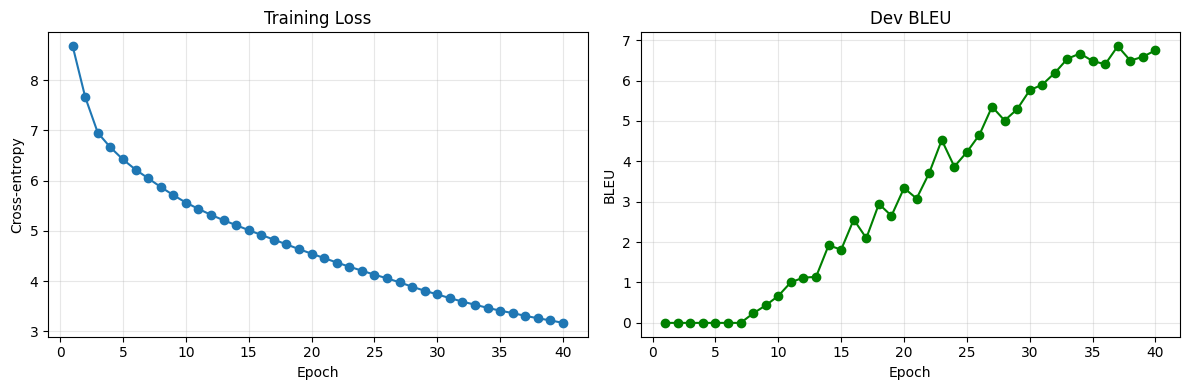

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, len(history["train_loss"])+1), history["train_loss"], marker="o")
ax[0].set_title("Training Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Cross-entropy"); ax[0].grid(alpha=.3)
ax[1].plot(range(1, len(history["dev_bleu"])+1), history["dev_bleu"], marker="o", color="green")
ax[1].set_title("Dev BLEU"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("BLEU"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("training_curves.png", dpi=120); plt.show()

In [14]:
@torch.no_grad()
def beam_search(model, src_ids, beam_size=5, max_len=128, alpha=0.7):
    model.eval()
    src = torch.tensor(src_ids, device=DEVICE).unsqueeze(0)
    src_mask = model.make_src_mask(src)
    mem = model.encode(src, src_mask)
    mem = mem.expand(beam_size, -1, -1)
    src_mask_b = src_mask.expand(beam_size, -1, -1, -1)

    beams = torch.full((beam_size, 1), BOS, dtype=torch.long, device=DEVICE)
    scores = torch.full((beam_size,), float("-inf"), device=DEVICE); scores[0] = 0.0
    finished = []

    for _ in range(max_len):
        k = beams.size(0)
        tgt_mask = model.make_tgt_mask(beams)
        logits = model.decode(beams, mem[:k], tgt_mask, src_mask_b[:k])
        logp = F.log_softmax(logits[:, -1], dim=-1)
        V = logp.size(-1)
        cand = (scores.unsqueeze(1) + logp).view(-1)
        top_s, top_i = cand.topk(k)
        beam_idx, tok_idx = top_i // V, top_i % V
        beams = torch.cat([beams[beam_idx], tok_idx.unsqueeze(1)], dim=1)
        scores = top_s
        keep = []
        for i in range(k):
            if tok_idx[i].item() == EOS:
                seq = beams[i, 1:-1].tolist()
                lp = ((5 + len(seq)) / 6) ** alpha
                finished.append((scores[i].item() / lp, seq))
            else:
                keep.append(i)
        if not keep:
            break
        keep = torch.tensor(keep, device=DEVICE)
        beams, scores = beams[keep], scores[keep]
        if len(finished) >= beam_size:
            break
    if not finished:
        finished = [(scores[i].item(), beams[i, 1:].tolist()) for i in range(beams.size(0))]
    best = max(finished, key=lambda x: x[0])[1]
    return sp_tgt.decode(best)

def translate_all(model, sentences, beam_size, max_len, alpha):
    outs = []
    for s in sentences:
        ids = [BOS] + sp_src.encode(str(s))[:max_len-2] + [EOS]
        outs.append(beam_search(model, ids, beam_size, max_len, alpha))
    return outs

In [15]:
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bertscore

def compute_bleu(hyps, refs):
    refs_tok = [[r.split()] for r in refs]
    hyps_tok = [h.split() for h in hyps]
    return corpus_bleu(refs_tok, hyps_tok) * 100

def compute_bertscore_f1(hyps, refs):
    P, R, F1 = bertscore(hyps, refs, lang="en", rescale_with_baseline=True, verbose=False)
    return F1.mean().item()

In [16]:
dev_hyps = translate_all(model, dev_df.Sentence_sa.tolist(),
                         CFG["beam_size"], CFG["max_len"], CFG["length_alpha"])
dev_refs = dev_df.Sentence_en.tolist()
dev_bleu_final = compute_bleu(dev_hyps, dev_refs)
dev_bert_f1 = compute_bertscore_f1(dev_hyps, dev_refs)
print(f"DEV  BLEU (beam):      {dev_bleu_final:.2f}")
print(f"DEV  BERTScore F1:     {dev_bert_f1:.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DEV  BLEU (beam):      7.55
DEV  BERTScore F1:     0.3186


In [17]:
test_df = load_pairs(TEST_SA, TEST_EN) if TEST_EN else pd.read_csv(TEST_SA)
if TEST_EN:
    test_srcs = test_df.Sentence_sa.tolist()
    test_ids  = test_df.Source_id.tolist()
else:
    test_df["Sentence_sa"] = test_df["Sentence_sa"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip()
    test_srcs = test_df.Sentence_sa.tolist()
    test_ids  = test_df.Source_id.tolist()


if DEVICE == "cuda": torch.cuda.synchronize()
t0 = time.time()
test_hyps = translate_all(model, test_srcs, CFG["beam_size"], CFG["max_len"], CFG["length_alpha"])
if DEVICE == "cuda": torch.cuda.synchronize()
INFERENCE_TIME = time.time() - t0

print(f"=== EFFICIENCY ===")
print(f"Total inference time (test set): {INFERENCE_TIME:.2f} s "
      f"({INFERENCE_TIME/len(test_srcs)*1000:.1f} ms/sentence)")
print(f"Total model parameters:          {TOTAL_PARAMS:,}")

if TEST_EN:
    test_refs = test_df.Sentence_en.tolist()
    test_bleu = compute_bleu(test_hyps, test_refs)
    test_bert = compute_bertscore_f1(test_hyps, test_refs)
    print(f"\n=== TEST SCORES ===")
    print(f"TEST BLEU:          {test_bleu:.2f}")
    print(f"TEST BERTScore F1:  {test_bert:.4f}")

=== EFFICIENCY ===
Total inference time (test set): 140.01 s (140.0 ms/sentence)
Total model parameters:          11,469,824


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== TEST SCORES ===
TEST BLEU:          7.47
TEST BERTScore F1:  0.3229


In [18]:
import pandas as pd
n_show = min(10, len(test_hyps))
ex = pd.DataFrame({
    "Source_id": test_ids[:n_show],
    "Sanskrit":  test_srcs[:n_show],
    "Prediction": test_hyps[:n_show],
})
if TEST_EN:
    ex.insert(2, "Reference", test_df.Sentence_en.tolist()[:n_show])
pd.set_option("display.max_colwidth", 80)
ex

,Source_id,Sanskrit,Reference,Prediction
0,1,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।,Eclipse also helps the programmer to find out errors.,We will also learn how to identify the error.
1,2,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्व...,"""We having the same spirit of faith, according as it is written, I believed,...","""In whom we have heard these things as well as well as our eyes, they are in..."
2,3,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।",Then it will automatically begin searching for drivers. I will click on Cancel.,"Next, I will click on the mopop to the mopopopop that is at the top of the t..."
3,4,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्यस...",The iterator will be set to each of the indices values for each iteration- s...,We have already written the identity of the sake of the sake of the sake of ...
4,5,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य प्राणिन आगत्य पश्येति वाक् मय...,"""And when he had opened the second seal, I heard the second beast say, Come ...","""And the second time I am in the second time, when I am at the other time of..."
5,6,"वयम्, ओब्जेक्ट्स् स्वकीयान् स्थितीन् फील्ड्स् मध्ये स्टोर् कुर्वन्तीति ज्ञात...",We know that objects store their individual states in fields.,We print the objects at the bottom of the objects.
6,7,बाल: युष्मासु विश्वासं करोति ।,Boy has belief on you all.,Child exhibits trust in you all.
7,8,प्रकृति का अवलोकन करने से आप आश्चर्य चकित हो सकते है ।,Observing the nature helps create a sense of wonder in you.,We can also understand the meaning of nature and their own nature.
8,9,यूयं कीदृक् तस्याज्ञा अपालयत भयकम्पाभ्यां तं गृहीतवन्तश्चैतस्य स्मरणाद् युष्...,"""And his inward affection is more abundant toward you, whilst he remembereth...","""To whom he gave us to give tribute unto you, and to morrow, and to morrow, ..."
9,10,"""वर्षाया: जलस्य कश्चन अंश: भूमौ शुष्को भूत्वा अन्तर्भवति,तदेव एकत्र आगत्य भौ...",A part of rain water is absorbedby earth. Water collected under the earth is...,"""Another is important to be placed in the month of A year, which is cooked b..."


In [19]:
submission = pd.DataFrame({"Source_id": test_ids, "Sentence_en": test_hyps})
submission.to_csv("submission.csv", index=False, encoding="utf-8")
print("Wrote submission.csv with", len(submission), "rows")
submission.head()

Wrote submission.csv with 1000 rows


,Source_id,Sentence_en
0,1,We will also learn how to identify the error.
1,2,"""In whom we have heard these things as well as well as our eyes, they are in..."
2,3,"Next, I will click on the mopop to the mopopopop that is at the top of the t..."
3,4,We have already written the identity of the sake of the sake of the sake of ...
4,5,"""And the second time I am in the second time, when I am at the other time of..."


In [20]:
torch.save({"model_state": model.state_dict(), "cfg": CFG}, "nmt_model.pt")
print("Saved: nmt_model.pt, spm_sa.model, spm_en.model")
print("Artifacts for submission ZIP: submission.csv, this notebook (.ipynb), report (PDF).")

Saved: nmt_model.pt, spm_sa.model, spm_en.model
Artifacts for submission ZIP: submission.csv, this notebook (.ipynb), report (PDF).


In [21]:
print("FINAL SUMMARY")
print(f"  Dev  BLEU:         {dev_bleu_final:.2f}")
print(f"  Dev  BERTScore F1: {dev_bert_f1:.4f}")
if TEST_EN:
    print(f"  Test BLEU:         {test_bleu:.2f}")
    print(f"  Test BERTScore F1: {test_bert:.4f}")
print(f"  Inference time:    {INFERENCE_TIME:.2f} s over {len(test_srcs)} sentences")
print(f"  Total parameters:  {TOTAL_PARAMS:,}")

FINAL SUMMARY
  Dev  BLEU:         7.55
  Dev  BERTScore F1: 0.3186
  Test BLEU:         7.47
  Test BERTScore F1: 0.3229
  Inference time:    140.01 s over 1000 sentences
  Total parameters:  11,469,824
